Unemployment Analysis

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [21]:
print(unemp.shape)
print(unemp.columns)
print(unemp.info())

(267, 9)
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                 

Data Cleaning
Rename columns for clarity

In [22]:
df.columns = [
    "state", "date", "frequency",
    "unemployment_rate", "employed",
    "labour_rate", "zone",
    "longitude", "latitude"
]

convert data format - Remove spaces,Convert to datetime

In [23]:
df["date"] = df["date"].astype(str).str.strip()
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

In [24]:
print(df.isnull().sum()) #check null values
df = df.dropna()

state                0
date                 0
frequency            0
unemployment_rate    0
employed             0
labour_rate          0
zone                 0
longitude            0
latitude             0
dtype: int64


In [25]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [18]:
print("Average Unemployment Rate:", df["unemployment_rate"].mean())

Average Unemployment Rate: 12.236928838951311


State-wise Analysis

In [26]:
state_avg = (
    df.groupby("state")["unemployment_rate"]
    .mean()
    .sort_values(ascending=False)
)

print(state_avg.head(10))

state
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Name: unemployment_rate, dtype: float64


In [27]:
#zone wise
zone_avg = df.groupby("zone")["unemployment_rate"].mean() 
print(zone_avg)

zone
East         13.916000
North        15.889620
Northeast    10.950263
South        10.454667
West          8.239000
Name: unemployment_rate, dtype: float64


Visualizations


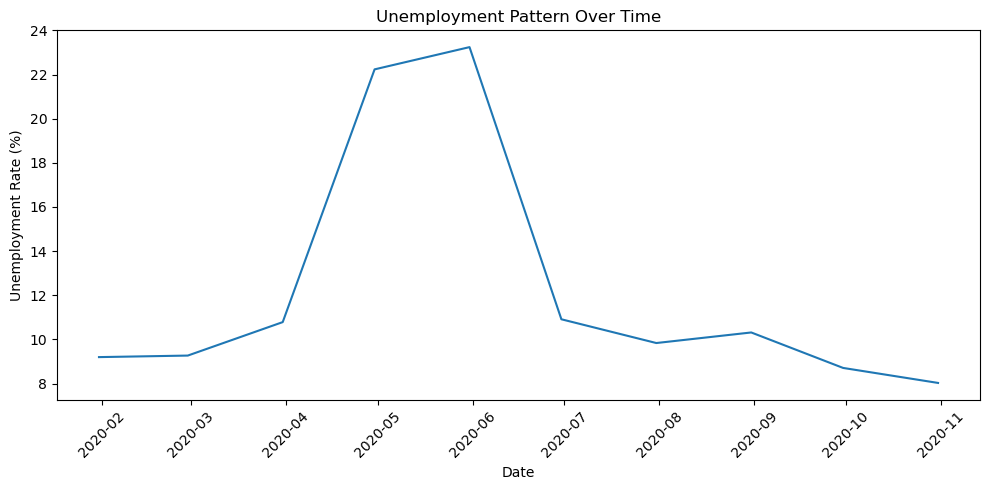

In [76]:
# Unemployment Pattern Over Time, Group by date and take average unemployment rate
pattern = df.groupby('date')['unemployment_rate'].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    x='date',
    y='unemployment_rate',
    data=pattern
)

plt.title("Unemployment Pattern Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

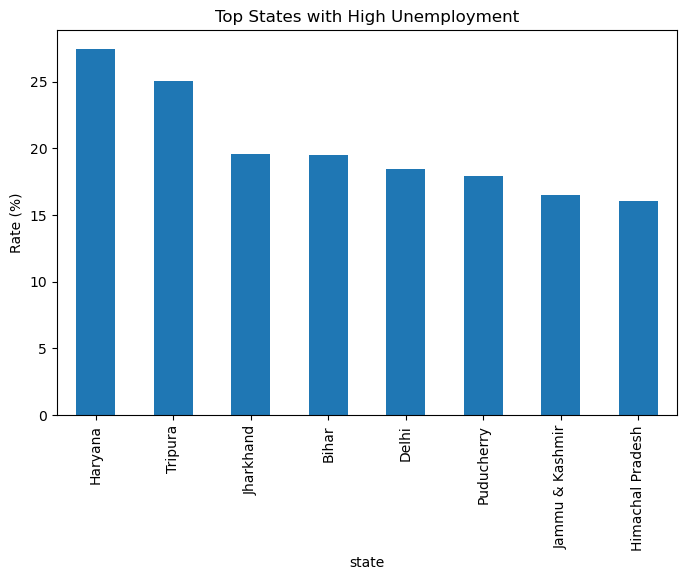

In [30]:
top_states = state_avg.head(8)

plt.figure(figsize=(8,5))
top_states.plot(kind="bar")

plt.title("Top States with High Unemployment")
plt.ylabel("Rate (%)")
plt.show()

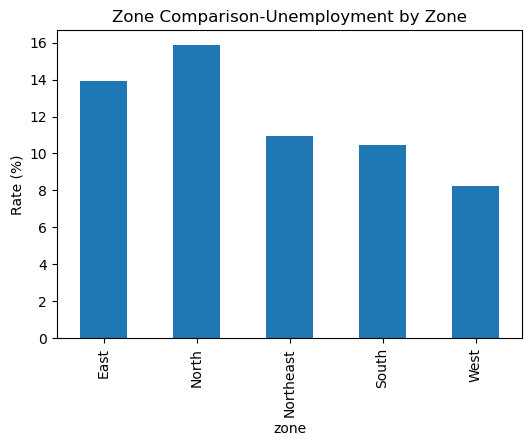

In [34]:
plt.figure(figsize=(6,4))

zone_avg.plot(kind="bar")

plt.title("Zone Comparison-Unemployment by Zone")
plt.ylabel("Rate (%)")
plt.show()

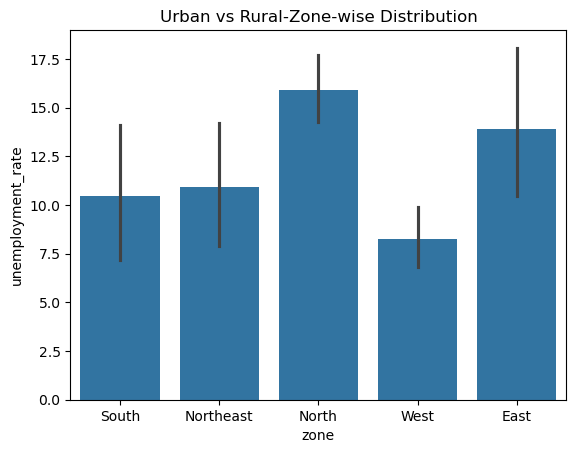

In [33]:
sns.barplot(
    x="zone",
    y="unemployment_rate",
    data=df
)

plt.title("Urban vs Rural-Zone-wise Distribution")
plt.show()

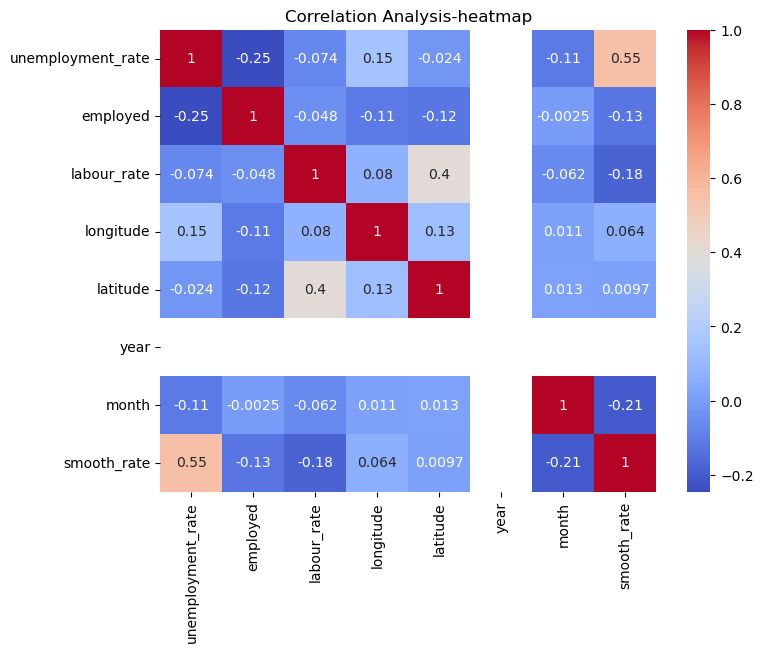

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Analysis-heatmap")
plt.show()

In [38]:
#COVID Impact Analysis
yearly_data = df.groupby("year")["unemployment_rate"].mean()
print(yearly_data)

year
2020    12.236929
Name: unemployment_rate, dtype: float64


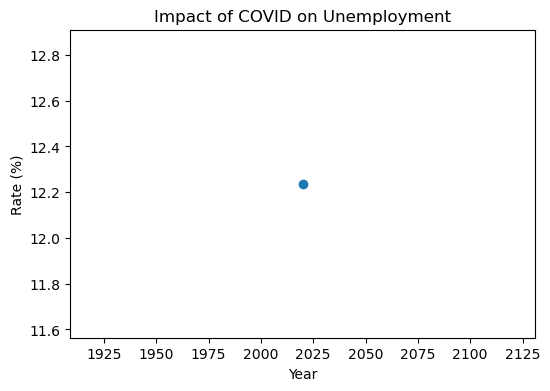

In [39]:
plt.figure(figsize=(6,4))

yearly_data.plot(marker='o')

plt.title("Impact of COVID on Unemployment")
plt.xlabel("Year")
plt.ylabel("Rate (%)")

plt.show()

Location-based Scatter Plot (uses latitude & longitude)

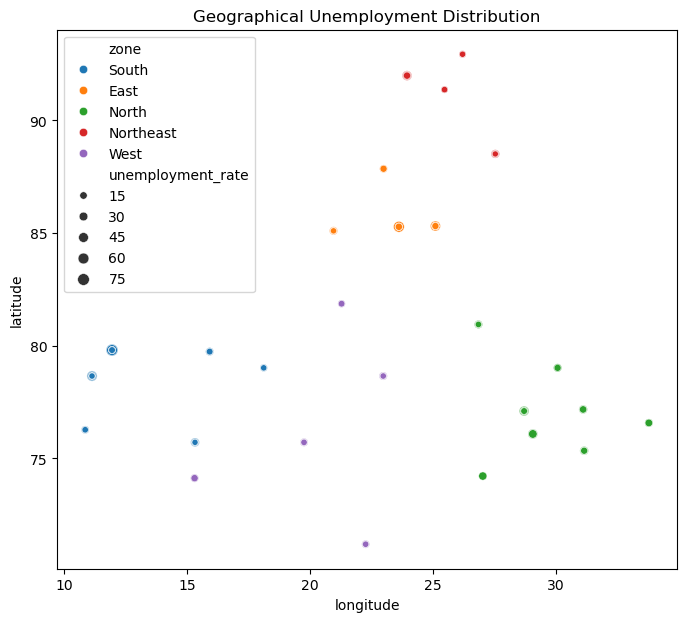

In [46]:
plt.figure(figsize=(8,7))
sns.scatterplot(
    x="longitude",
    y="latitude",
    size="unemployment_rate",
    hue="zone",
    data=df
)
plt.title("Geographical Unemployment Distribution")
plt.show()

In [63]:
df1= pd.read_csv("Unemployment in India.csv")

print(df.columns)

Index(['state', 'date', 'frequency', 'unemployment_rate', 'employed',
       'labour_rate', 'zone', 'longitude', 'latitude', 'year', 'month',
       'smooth_rate'],
      dtype='object')


In [58]:
df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), dayfirst=True)
df.columns = df.columns.str.strip()

C:\Users\sandh\AppData\Local\Temp\ipykernel_9980\1485554088.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"].astype(str).str.strip(), dayfirst=True)


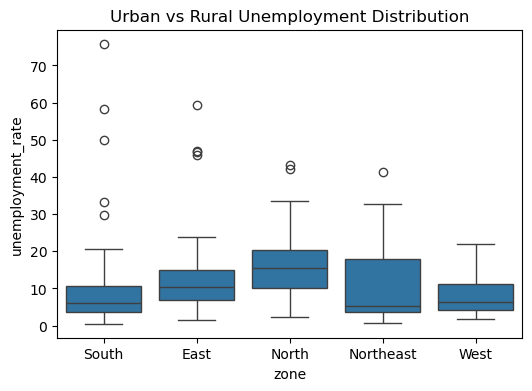

In [64]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x="zone",
    y="unemployment_rate",
    data=df
)

plt.title("Urban vs Rural Unemployment Distribution")
plt.show()